
# Lab_5: FEM 1D

En primera instancia, quisiera hacer una revisión del contenido del notebook. Hay ciertas inconsistencias que parecen ser clave para entender tanto el problema como la solución. Por supuesto, esta discusión nada tiene que ver con resolver el laboratorio, pero sí abre un espacio para poner a prueba ideas propias (hasta que mi querido lector lo revise y me dé su apreciación); quizá en esta divagación de un terco se encuentre algo interesante.

La primera sorpresa surgió en la descomposición espectral,
$$U(x)=\sum_{j=0}^{N-1}\alpha_j\phi_j(x),$$
y aquí aparece la primera pregunta incómoda: ¿por qué empezar desde 0? ¿por qué no desde 1?

Claro, siempre se puede responder que da lo mismo, que es solo una convención, y además que resulta más “natural” comenzar desde cero porque así empieza Python. La segunda afirmación puede ser cuestión de gustos; la primera, en cambio, es una cuestión de consistencia. Si se escoge el 0 como inicio, debe mantenerse esa convención para evitar malinterpretaciones. Y es fácil caer en ese desliz cuando se empieza desde cero, como se verá más adelante. Cabe resaltar, además, que esta descomposición se exige que se anule en los bordes, una condición importantísima, pues de lo contrario podría entenderse que la expansión se está haciendo solo sobre los puntos en que se divide el intervalo de la EDO, como parece sugerirse. Y eso sería, cuando menos, una invitación al enredo, porque en los extremos ya conocemos la función gracias a las condiciones de Dirichlet.

Lo siguiente es la definición de la función sombrero. En el notebook aparece como:
\begin{equation}
\phi_i(x) =
\begin{cases}
0, & \text{for } x < x_{i-1}, \text{ or } x > x_{i+1}, \\[6pt]
\dfrac{x - x_{i-1}}{h_i}, & \text{for } x_{i-1} \le x \le x_i, \\[10pt]
\dfrac{x_{i+1} - x}{h_i}, & \text{for } x_i \le x \le x_{i+1},
\end{cases}
\quad \left( h_i = x_{i+1} - x_i \right).
\end{equation}
Se nos señala que la función en $x_i$ es igual a $1$. Pero, así como está escrita, eso solo es válido si h_i = h_{i-1}, cosa que se menciona casi de pasada al comienzo del notebook. Y, por supuesto, eso no es necesariamente cierto. Para que se cumpla que $\phi_i(x_i) = 1$, es más intuitivo definir (fíjese, mi querido lector, en la segunda línea)

\begin{equation}
\phi_i(x) =
\begin{cases}
0, & \text{for } x < x_{i-1}, \text{ or } x > x_{i+1}, \\[6pt]
\dfrac{x - x_{i-1}}{h_{i-1}}, & \text{for } x_{i-1} \le x \le x_i, \\[10pt]
\dfrac{x_{i+1} - x}{h_i}, & \text{for } x_i \le x \le x_{i+1},
\end{cases}
\quad \left( h_i = x_{i+1} - x_i \right).
\end{equation}

En esta definición aparece de inmediato otro problema: ¿quiénes son exactamente los $x_i$ sobre los que se define $\phi_i$?, ¿quién es $\phi_0$ y por qué le aparece un $h_{-1}$? De pasadita (no de manera directa) se explica que los $x_i$ son los puntos del intervalo que se toman como representativos del intervalo, los nodos. Para este caso son equidistante, pero no toman los bordes, porque si los bordes fueran un nodo $\phi_0(x_0)=1$, cuando se nos exigío que cuando se hacía la expansión esta se anulara en los bordes para todos los $\Phi$. Por su definición, $\phi_0$ no se anula en el borde, tampoco $\phi_N$, aunque de este último no se hace uso

En cambio, si se tomara la definición de $\phi$ que propongo, se empezara la sumatoria por 1 y se explicara explícitamente que el intervalo $[a,b]$ se divide en una malla) $[x_0, x_1, ..., x_{N+1}]$, donde $x_i = a + \frac{b-a}{N+1}*i$, ($x_0 = a$ y $x_{N+1}=b$), teniendo N+1 elementos. Así, $U(x)=\sum_{j=1}^{N}\alpha_j\phi_j(x)$, sin todavía incluir los bordes. 

El problema de la notación se hace plausible cuando construye la matriz de rigidez.
Reemplazando la expansión de $U$ en la forma débil de la EDO, nos que dan N ecuaciones lineales para $\alpha_i$ con $ i = 1, ..., N$. Las componentes de la matriz de rigidez toman la forma
$$
A_{ij} = \int_a^b \phi'_{i} \phi'_{j} \, dx
$$
Es claro que e suna matriz simétrica NxN. Además, por la definición de las funciones sombrero, basta calcular las posisciones $a_{ii}$ y $a_{ii+1}$

En el notebook se pone que (dejando ver la correcta definición de $\phi$, augurando simplemnte un error de escritura)

\begin{equation}
\frac{d\phi_{i}}{dx} =
\begin{cases}
0, & x < x_{i-1}, \text{ or } x_{i+1} < x, \\[6pt]
\dfrac{1}{h_{i-1}}, & x_{i-1} \le x \le x_i, \\[10pt]
-\dfrac{1}{h_i}, & x_i \le x \le x_{i+1},
\end{cases}
\end{equation}

De esta forma, no es difícil ver que 
$$
A_{ii} = \frac{1}{h_{i-1}} + \frac{1}{h_i} \\
A_{ii+1} = -\frac{1}{h_i}
$$

Si las ecuaciones empiezan desde el $\alpha_0$, como se deja en el notebook, el primer término de la matriz queda de la forma $a_{00} = \frac{1}{h_{-1}}+\frac{1}{h_{0}}$. Pero el notebook, como tomando un el buen camino de haber empezado la sumatoria desde 1, escribe explícitamente la matriz de rigidez como:

$
\mathbf{A} =
\begin{pmatrix}
\frac{1}{h_0} + \frac{1}{h_1} & -\frac{1}{h_1} & 0 & \cdots & 0 \\
-\frac{1}{h_1} & \frac{1}{h_1} + \frac{1}{h_2} & -\frac{1}{h_2} & \cdots & 0 \\
0 & -\frac{1}{h_2} & \frac{1}{h_2} + \frac{1}{h_3} & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & -\frac{1}{h_{N-2}} \\
0 & 0 & 0 & -\frac{1}{h_{N-2}} & \frac{1}{h_{N-2}} + \frac{1}{h_{N-1}}
\end{pmatrix}.
$

Esta deifinición me parece adecuada siempre que se haya empezado desde 1.

Lo que queda faltando es incluir las condiciones de frontera, que en el notebook se hace sumando $U_a\,\phi_0(x) + U_b\,\phi_{N-1}(x)$, el problema es que estas $\phi's$ explícitamente se dice que se anulan en las fronteras. Por eso propongo una definición alterna, con $\phi_0$ y $\phi_N$

\begin{equation}
\phi_0(x) =
\begin{cases}
0, & \text{for } x < a, \text{ or } x > x_{1}, \\[6pt]
\dfrac{x_{1} - x}{h_0}, & \text{for } x_0 \le x \le x_{1}, \\[10pt]
\end{cases}
\quad \left( h_0 = x_{1} - x_0 \right).
\end{equation}

\begin{equation}
\phi_{N+1}(x) =
\begin{cases}
0, & \text{for } x < x_{N}, \text{ or } x > b, \\[6pt]
\dfrac{x - x_{N}}{h_N}, & \text{for } x_{N} \le x \le b, \\[10pt]
\end{cases}
\quad \left( h_N = b - x_N \right).
\end{equation}


$\alpha_0=U(a)$ y $\alpha_{N+1}=U(b)$
Con estas definiciones,  $U(x)=\sum_{j=0}^{N+1}\alpha_j\phi_j(x)$, pero es claro que no debemos preocuparnos por los coeficientes añadidos, porque por la definición de $\phi's$ $\alpha_0=U(a)$ y $\alpha_{N+1}=U(b)$. Con estas aclaraciones se pueden incluir los bordes desde un inicio y ahorrarse una aparición artificial de las contribuciones de los bordes. Me parece (es solo una apreciación, con la única intención de reflexión) que es más fácil hacer la expansión directamente de esta forma y escribir las ecuaciones lineales a resolver:

\begin{align*}
\alpha_1 a_{11} + \alpha_2 a_{12} + \cdots + \alpha_{N} a_{1N} + U_a\int_a^b \phi_0'\phi_1'\,dx + U_b\int_a^b \phi_{N+1}'\phi_1'\,dx &= \int_a^b 4\pi\rho\,\phi_1 \, dx \\[6pt]
\alpha_1 a_{21} + \alpha_2 a_{22} + \cdots + \alpha_{N} a_{2N} + U_a\int_a^b \phi_0'\phi_2'\,dx + U_b\int_a^b \phi_{N+1}'\phi_2'\,dx &= \int_a^b 4\pi\rho\,\phi_2 \, dx, \\
&\vdots \\
\alpha_1 a_{N1} + \alpha_2 a_{N2} + \cdots + \alpha_{N} a_{NN} + U_a\int_a^b \phi_0'\phi_N'\,dx + U_b\int_a^b \phi_{N+1}'\phi_N'\,dx &= \int_a^b 4\pi\rho\,\phi_N \, dx,\\
\end{align*}

Una expresión a resolver mucho más compacta, más legible.

La cuestión que ahora surge, ¿funciona?
Vamos a intentarlo con el ejemplo del notebook

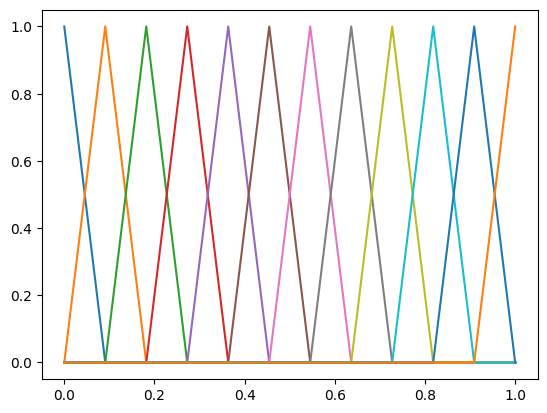

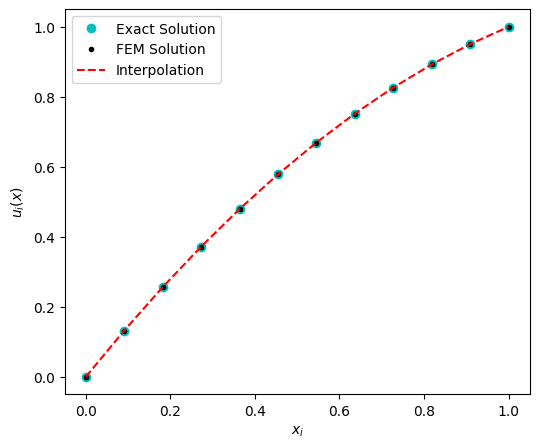

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
# Como siempre, definimos primero el espacio de trabajo, vamos a  trabajar en el intervalo [0,1], tomemos funciones con 100 puntos dentro
# dejemos el número de puntos en el intervalo como una variable, por si acaso (good praxis)¨
a,b = 0,1
n = 100
x = np.linspace(a,b, n)
# Hay que hacer las divisiones del array, para esto vamos a definir una función que se le pase un N y me devuelva el array
# de N elementos de los elementos del array que me representa el espacio, x.
def muestra_equidis(N,x):
    idx = np.linspace(0, len(x)-1, N + 2)[1:-1]
    idx = np.round(idx).astype(int)
    return x[idx]
# Por la notación del notebook, llamemos xi a los nodos internos
# Tomemos  N puntos,   empecemos  por 10
N = 10 # Este N termina siendo el tamaño de nuestra matriz de rigidez
xi_ = muestra_equidis(N,x)
#  Tomemos también los  bordes, así estos tiene índice 0 y N+1.
xi = np.concatenate(([a], xi_, [b]))

# Definamos las funciones base, las de la matriz de rigidez y las de las condiciones de frontera
def phi(i,x):
    fun = np.zeros(n)
    if i == 0:
        mask = (x >= xi[0]) & (x <= xi[1])
        fun[mask] = (xi[1]-x[mask])/(xi[1]-xi[0])
        return fun
    if i ==  N+1:
        mask = (x>=xi[N])&(x<=xi[N+1])
        fun[mask] = (x[mask]-xi[N])/(xi[N+1]-xi[N])
        return fun
    else:
        mask1 = (x>=xi[i-1])&(x<=xi[i])
        mask2 = (x>xi[i])&(x<=xi[i+1])
        fun[mask1] = (x[mask1]-xi[i-1])/(xi[i]-xi[i-1])
        fun[mask2] = (xi[i+1]-x[mask2])/(xi[i+1]-xi[i])
        return fun

for  i in range(0,N+2):
    plt.plot(x, phi(i,x)) # Voy a dejar esta gráfica, me pareció bonita
plt.show()
# Una vez definidas nuestras funciones base deberíamos pasar a definir la matriz de rigidez y para eso, las derivadas de estas funciones base
# a mí me agrada poner a trabajar a las máquinas, no voy a optimizar  nada,  sino a trabajarlo de la manera más intuitiva,  la optimización 
# dejarla para un repaso posterior.
def phi_prima(i,x):
    fun = np.zeros(n)
    if i == 0:
        mask = (x >= xi[0]) & (x <= xi[1])
        fun[mask] = (-1)/(xi[1]-xi[0])
        return fun
    if i ==  N+1:
        mask = (x>=xi[N])&(x<=xi[N+1])
        fun[mask] = (1)/(xi[N+1]-xi[N])
        return fun
    else:
        mask1 = (x>=xi[i-1])&(x<=xi[i])
        mask2 = (x>xi[i])&(x<=xi[i+1])
        fun[mask1] = (1)/(xi[i]-xi[i-1])
        fun[mask2] = (-1)/(xi[i+1]-xi[i])
        return fun 
# Ahora hay que definir cómo carajos integrar... me da pereza, voy tomar la def. analítica.
A = np.zeros((N,N))

for i in range(N):
    h_i = xi[i+1] - xi[i]
    h_ip1 = xi[i+2] - xi[i+1]
    
    A[i,i] = 1/h_i + 1/h_ip1
    
    if i > 0:
        A[i,i-1] = -1/h_i
    if i < N-1:
        A[i,i+1] = -1/h_ip1
# Ya que tenemos la matriz de rigidez, vamos con el vector de carga.
# Tiene N elementos 
# Necesitamos  las condiciones de frontera
Ua = 0
Ub = 1
b = np.zeros(N)
for i in range(1,N+1):
    if i==1:
        b[0] = np.trapezoid(phi(1,x),x=x) + Ua*(1/(xi[i]-xi[i-1]))
        continue
    if i== N:
        b[i-1] = np.trapezoid(phi(i,x),x=x) + Ub*(1/(xi[i]-xi[i-1]))
    else:
        b[i-1] = np.trapezoid(phi(i,x),x=x)
sol = np.linalg.solve(A, b )
U_approx = np.concatenate(([Ua], sol, [Ub]))

y_new = np.interp(x, xi, U_approx)
def exact( x ):
    u = - x*(x - 3)/2
    return u
plt.figure(figsize=(6, 5))
plt.plot(xi, exact(xi),'co', label='Exact Solution')
plt.plot(xi, U_approx,'k.', label='FEM Solution')
plt.plot(x, y_new,'r--', label='Interpolation')
plt.xlabel(r'$x_i$')
plt.ylabel(r'$u_i(x)$')
plt.legend(loc='best')
plt.show()

### Exercise 1: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(2-x)-x
\end{equation}

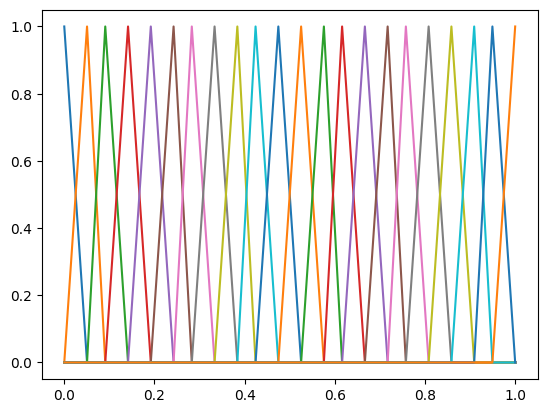

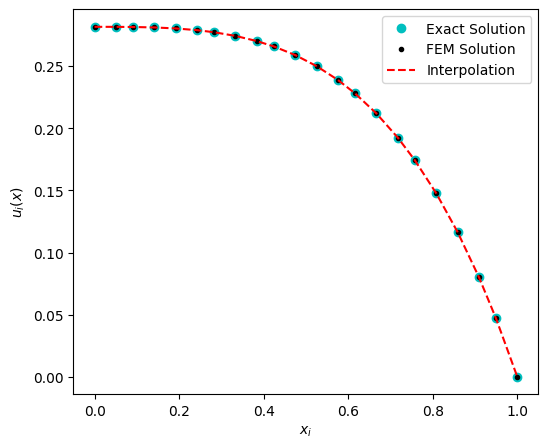

In [ ]:
# Ya hecho tooooooodo el análisis anterior, me puedo pasar por el forro el construir el script, ya lo tengo (ver la parte de arriba)
# lo que hay que cambiar el es vector de carga y las condiciones de frontera, por supuesto, 
# también la definición de la solución exacta a comparar. En mi humilde opinión
# 
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
# Como siempre, definimos primero el espacio de trabajo, vamos a  trabajar en el intervalo [0,1], tomemos funciones con 100 puntos dentro
# dejemos el número de puntos en el intervalo como una variable, por si acaso (good praxis)¨
a,b = 0,1
n = 100
x = np.linspace(a,b, n)
# Hay que hacer las divisiones del array, para esto vamos a definir una función que se le pase un N y me devuelva el array
# de N elementos de los elementos del array que me representa el espacio, x.
def muestra_equidis(N,x):
    idx = np.linspace(0, len(x)-1, N + 2)[1:-1]
    idx = np.round(idx).astype(int)
    return x[idx]
# Por la notación del notebook, llamemos xi a los nodos internos
# Tomemos  N puntos,   empecemos  por 10
N = 20 # Este N termina siendo el tamaño de nuestra matriz de rigidez
xi_ = muestra_equidis(N,x)
#  Tomemos también los  bordes, así estos tiene índice 0 y N+1.
xi = np.concatenate(([a], xi_, [b]))

# Definamos las funciones base, las de la matriz de rigidez y las de las condiciones de frontera
def phi(i,x):
    fun = np.zeros(n)
    if i == 0:
        mask = (x >= xi[0]) & (x <= xi[1])
        fun[mask] = (xi[1]-x[mask])/(xi[1]-xi[0])
        return fun
    if i ==  N+1:
        mask = (x>=xi[N])&(x<=xi[N+1])
        fun[mask] = (x[mask]-xi[N])/(xi[N+1]-xi[N])
        return fun
    else:
        mask1 = (x>=xi[i-1])&(x<=xi[i])
        mask2 = (x>xi[i])&(x<=xi[i+1])
        fun[mask1] = (x[mask1]-xi[i-1])/(xi[i]-xi[i-1])
        fun[mask2] = (xi[i+1]-x[mask2])/(xi[i+1]-xi[i])
        return fun

for  i in range(0,N+2):
    plt.plot(x, phi(i,x)) # Voy a dejar esta gráfica, me pareció bonita
plt.show()
# Una vez definidas nuestras funciones base deberíamos pasar a definir la matriz de rigidez y para eso, las derivadas de estas funciones base
# a mí me agrada poner a trabajar a las máquinas, no voy a optimizar  nada,  sino a trabajarlo de la manera más intuitiva,  la optimización 
# dejarla para un repaso posterior.
def phi_prima(i,x):
    fun = np.zeros(n)
    if i == 0:
        mask = (x >= xi[0]) & (x <= xi[1])
        fun[mask] = (-1)/(xi[1]-xi[0])
        return fun
    if i ==  N+1:
        mask = (x>=xi[N])&(x<=xi[N+1])
        fun[mask] = (1)/(xi[N+1]-xi[N])
        return fun
    else:
        mask1 = (x>=xi[i-1])&(x<=xi[i])
        mask2 = (x>xi[i])&(x<=xi[i+1])
        fun[mask1] = (1)/(xi[i]-xi[i-1])
        fun[mask2] = (-1)/(xi[i+1]-xi[i])
        return fun 
# Ahora hay que definir cómo carajos integrar... me da pereza, voy tomar la def. analítica.
A = np.zeros((N,N))

for i in range(N):
    h_i = xi[i+1] - xi[i]
    h_ip1 = xi[i+2] - xi[i+1]
    
    A[i,i] = 1/h_i + 1/h_ip1
    
    if i > 0:
        A[i,i-1] = -1/h_i
    if i < N-1:
        A[i,i+1] = -1/h_ip1
# Ya que tenemos la matriz de rigidez, vamos con el vector de carga.
# Tiene N elementos 
# Necesitamos  las condiciones de frontera
Ua = 3 - np.exp(1)
Ub = 0
b = np.zeros(N)
def rho(x):
    return x*np.exp(x)

for i in range(1,N+1):
    if i==1:
        b[i-1] = np.trapezoid(phi(i,x)*rho(x),x=x) + Ua*(1/(xi[i]-xi[i-1]))
        continue
    if i== N:
        b[i-1] = np.trapezoid(phi(i,x)*rho(x),x=x) + Ub*(1/(xi[i]-xi[i-1]))
    else:
        b[i-1] = np.trapezoid(phi(i,x)*rho(x),x=x)
sol = np.linalg.solve(A, b )
U_approx = np.concatenate(([Ua], sol, [Ub]))

y_new = np.interp(x, xi, U_approx)
def exact( x ):
    return (1-np.exp(1)+np.exp(x)*(2-x)-x)
plt.figure(figsize=(6, 5))
plt.plot(xi, exact(xi),'co', label='Exact Solution')
plt.plot(xi, U_approx,'k.', label='FEM Solution')
plt.plot(x, y_new,'r--', label='Interpolation')
plt.xlabel(r'$x_i$')
plt.ylabel(r'$u_i(x)$')
plt.legend(loc='best')
plt.show()


### Exercise 2: Solve the EDO:  

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

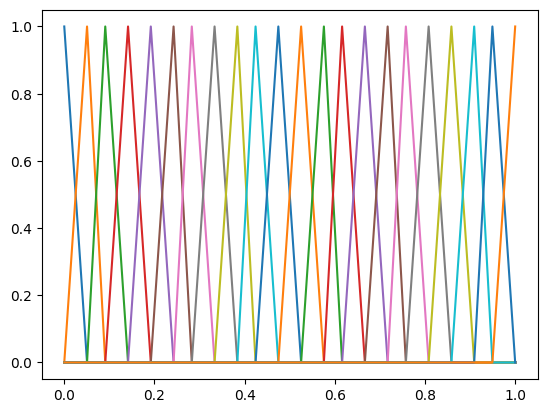

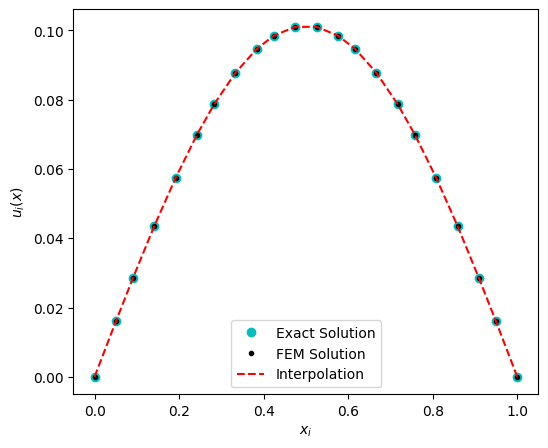

In [38]:
# Ya hecho tooooooodo el análisis anterior, me puedo pasar por el forro el construir el script, ya lo tengo (ver la parte de arriba)
# lo que hay que cambiar el es vector de carga y las condiciones de frontera, por supuesto, 
# también la definición de la solución exacta a comparar. En mi humilde opinión
# 
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
# Como siempre, definimos primero el espacio de trabajo, vamos a  trabajar en el intervalo [0,1], tomemos funciones con 100 puntos dentro
# dejemos el número de puntos en el intervalo como una variable, por si acaso (good praxis)¨
a,b = 0,1
n = 100
x = np.linspace(a,b, n)
# Hay que hacer las divisiones del array, para esto vamos a definir una función que se le pase un N y me devuelva el array
# de N elementos de los elementos del array que me representa el espacio, x.
def muestra_equidis(N,x):
    idx = np.linspace(0, len(x)-1, N + 2)[1:-1]
    idx = np.round(idx).astype(int)
    return x[idx]
# Por la notación del notebook, llamemos xi a los nodos internos
# Tomemos  N puntos,   empecemos  por 10
N = 20 # Este N termina siendo el tamaño de nuestra matriz de rigidez
xi_ = muestra_equidis(N,x)
#  Tomemos también los  bordes, así estos tiene índice 0 y N+1.
xi = np.concatenate(([a], xi_, [b]))

# Definamos las funciones base, las de la matriz de rigidez y las de las condiciones de frontera
def phi(i,x):
    fun = np.zeros(n)
    if i == 0:
        mask = (x >= xi[0]) & (x <= xi[1])
        fun[mask] = (xi[1]-x[mask])/(xi[1]-xi[0])
        return fun
    if i ==  N+1:
        mask = (x>=xi[N])&(x<=xi[N+1])
        fun[mask] = (x[mask]-xi[N])/(xi[N+1]-xi[N])
        return fun
    else:
        mask1 = (x>=xi[i-1])&(x<=xi[i])
        mask2 = (x>xi[i])&(x<=xi[i+1])
        fun[mask1] = (x[mask1]-xi[i-1])/(xi[i]-xi[i-1])
        fun[mask2] = (xi[i+1]-x[mask2])/(xi[i+1]-xi[i])
        return fun

for  i in range(0,N+2):
    plt.plot(x, phi(i,x)) # Voy a dejar esta gráfica, me pareció bonita
plt.show()
# Una vez definidas nuestras funciones base deberíamos pasar a definir la matriz de rigidez y para eso, las derivadas de estas funciones base
# a mí me agrada poner a trabajar a las máquinas, no voy a optimizar  nada,  sino a trabajarlo de la manera más intuitiva,  la optimización 
# dejarla para un repaso posterior.
def phi_prima(i,x):
    fun = np.zeros(n)
    if i == 0:
        mask = (x >= xi[0]) & (x <= xi[1])
        fun[mask] = (-1)/(xi[1]-xi[0])
        return fun
    if i ==  N+1:
        mask = (x>=xi[N])&(x<=xi[N+1])
        fun[mask] = (1)/(xi[N+1]-xi[N])
        return fun
    else:
        mask1 = (x>=xi[i-1])&(x<=xi[i])
        mask2 = (x>xi[i])&(x<=xi[i+1])
        fun[mask1] = (1)/(xi[i]-xi[i-1])
        fun[mask2] = (-1)/(xi[i+1]-xi[i])
        return fun 
# Ahora hay que definir cómo carajos integrar... me da pereza, voy tomar la def. analítica.
A = np.zeros((N,N))

for i in range(N):
    h_i = xi[i+1] - xi[i]
    h_ip1 = xi[i+2] - xi[i+1]
    
    A[i,i] = 1/h_i + 1/h_ip1
    
    if i > 0:
        A[i,i-1] = -1/h_i
    if i < N-1:
        A[i,i+1] = -1/h_ip1
# Ya que tenemos la matriz de rigidez, vamos con el vector de carga.
# Tiene N elementos 
# Necesitamos  las condiciones de frontera
Ua = 0
Ub = 0
b = np.zeros(N)
def rho(x):
    return np.sin(np.pi*x)

for i in range(1,N+1):
    if i==1:
        b[i-1] = np.trapezoid(phi(i,x)*rho(x),x=x) + Ua*(1/(xi[i]-xi[i-1]))
        continue
    if i== N:
        b[i-1] = np.trapezoid(phi(i,x)*rho(x),x=x) + Ub*(1/(xi[i]-xi[i-1]))
    else:
        b[i-1] = np.trapezoid(phi(i,x)*rho(x),x=x)
sol = np.linalg.solve(A, b )
U_approx = np.concatenate(([Ua], sol, [Ub]))

y_new = np.interp(x, xi, U_approx)
def exact( x ):
    return (1/np.pi**2)*np.sin(np.pi*x)
plt.figure(figsize=(6, 5))
plt.plot(xi, exact(xi),'co', label='Exact Solution')
plt.plot(xi, U_approx,'k.', label='FEM Solution')
plt.plot(x, y_new,'r--', label='Interpolation')
plt.xlabel(r'$x_i$')
plt.ylabel(r'$u_i(x)$')
plt.legend(loc='best')
plt.show()
